In [1]:
# import modules
import numpy as np
import random
import math
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

np.set_printoptions(suppress=True)

In [2]:
# First generate some synthetic data
# Generate random covariate fields
# We use 2 simulated covariates

L = 50.0 # size of domain
x = y = np.arange(0,L+1,1)
var=1.0

2022-11-01 13:43:45.536192: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-11-01 13:43:46.044013: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14805 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5
2022-11-01 13:43:46.199402: I tensorflow/core/util/cuda_solvers.cc:180] Creating CudaSolver handles for stream 0x558c96ea14f0


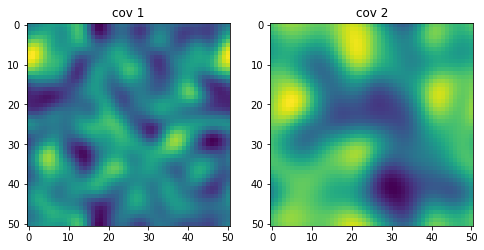

In [3]:
# Make the environment using a correlated periodic Gaussian random field

x = y = np.arange(0,L+1,1)
xx, yy = np.meshgrid(x,y)

positions = np.vstack([xx.ravel(), yy.ravel()]).T

len_scale_1 = 5
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_1*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov1 = samples.numpy().reshape(51,51)


len_scale_2 = 10
period = np.float64(L)
periodic_len = (2**0.5)*len_scale_2*np.pi/period


kernel = tfp.math.psd_kernels.ExpSinSquared(length_scale=periodic_len,period=period)
gp = tfd.GaussianProcess(kernel, positions)

samples = gp.sample()
cov2 = samples.numpy().reshape(51,51)


fig, ax = plt.subplots(1,2,figsize=(8,6))
ax[0].set_title('cov 1')
ax[0].imshow(cov1)
ax[1].set_title('cov 2')
ax[1].imshow(cov2)
plt.show()

cov_cube = np.stack((cov1,cov2))

In [4]:
# Simulating observation from centred model
 
nbObs=10001 #nbObs Number of observations
beta=np.array([[0.5,-0.8]]) # Vector of resource selection coefficients
allr=np.ones(nbObs) # Vector of radii for movement kernel, or standard deviations
cov=cov_cube #Array of covariates (one layer for each covariate)
xy0=[25,25] #Initial location
npts=100 # Number of potential endpoints to sample at each time step
xy1=np.zeros((nbObs,2))
xy1[0] = xy0
x_min = [0., 0.]
x_max = [L, L]
   
# Convert the covariates to tensor 
cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])
beta_tensor = tf.convert_to_tensor(beta,dtype=tf.float32)
    
C=np.zeros((2))
allrsf=np.zeros(npts)
dt = np.zeros(nbObs)
ID = np.zeros(nbObs)
cid=0
t = 1
for t in tqdm(range(1,nbObs)):
    cdt = np.random.normal(loc=1.0,scale=0.1)
    C[0] = np.random.normal(loc=xy1[t-1,0],scale=allr[t-1]*((0.5*cdt)**0.5))
    C[1] = np.random.normal(loc=xy1[t-1,1],scale=allr[t-1]*((0.5*cdt)**0.5))
        
    grid=np.zeros((npts,2))
    # sample npts points in the circle
    
    grid[:,0]=np.random.normal(loc=C[0], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)
    grid[:,1]=np.random.normal(loc=C[1], scale=allr[t-1]*((0.5*cdt)**0.5),size=npts)               
    
    # Convert grid to tensor before extracting the values
    zgrid=tf.convert_to_tensor(grid%L,dtype=tf.float32)

    # calculate the covariates at the step end locations using tensorflow probability
    cov_xy_end = tfp.math.batch_interp_regular_nd_grid(zgrid, x_min, x_max, cov_tensor, axis=-3)
            
    # calculate the rsf
    allrsf= np.array(tf.exp(tf.reduce_sum(tf.multiply(cov_xy_end,beta_tensor),axis=-1)))
        
    next_point=random.choices(population=grid,weights=allrsf,k=1)
    
    dt[t-1]=cdt
    xy1[t]=next_point[0] 
        
    ID[t]=cid

100%|██████████| 10000/10000 [00:50<00:00, 198.58it/s]


In [5]:
# A periodic version for working with simulated data on a torus

class stepSelectionVI(tf.Module):
    def __init__(self, n_covars, cov_tensor, move_std=1.0, L=1.0,  prior_mean=None, prior_std=None,n_gh_points=4,n_vi_samples=4):
               
      
        self.n_covars = n_covars
        self.cov_tensor = cov_tensor
        self.n_gh_points = n_gh_points
        self.n_vi_samples = n_vi_samples
        
        self.x_ref_min = [0., 0.]
        self.x_ref_max = [L, L]
        self.L = L # lengths of square periodic domain

        # set up the points for Gauss-Hermite quadrature
        xi, wi = np.polynomial.hermite.hermgauss(n_gh_points)

        ghx,ghy = np.meshgrid(xi,xi)
        self.gh_grid = tf.convert_to_tensor(np.stack([ghx,ghy],axis=2).astype(np.float32)) 

        ghx,ghy = np.meshgrid(wi,wi)
        
        self.grid_gh_weights = tf.convert_to_tensor(ghy,dtype=tf.float32)
        self.gh_weights = tf.convert_to_tensor(wi,dtype=tf.float32)
        
        self.beta_mean = tf.Variable(np.zeros((n_covars)),dtype=tf.float32)
        self.beta_std = tfp.util.TransformedVariable([np.ones(n_covars,dtype=np.float32)],tfp.bijectors.Softplus(),dtype=tf.float32)
        self.variational_posterior = tfp.distributions.MultivariateNormalDiag(loc = self.beta_mean, scale_diag=self.beta_std)
        
        self.move_std = tfp.util.TransformedVariable(move_std,tfp.bijectors.Softplus(),dtype=tf.float32)
        
        
        # set default prior to be N(0,10)
        if prior_mean is None:
            prior_mean = np.zeros((n_covars))
        if prior_std is None:
            prior_std = 10.0*np.ones((n_covars))
        prior_mean = tf.constant(prior_mean,dtype=tf.float32)
        prior_std = tf.constant(prior_std,dtype=tf.float32)
        self.prior = tfp.distributions.MultivariateNormalDiag(loc=prior_mean, scale_diag=prior_std)

    @tf.function
    def variational_loss(self, start_points_batch,end_points_batch,step_times_batch,kl_weight = 1.0):
        beta_samples = tf.random.normal((self.n_vi_samples,self.n_covars,1),dtype=tf.float32)
        beta_samples = (tf.expand_dims(self.beta_mean,axis=-1) + tf.linalg.matmul(self.beta_std,beta_samples))[...,0]
        
        elogp = tf.reduce_mean(self.log_likelhood(beta_samples,start_points_batch,end_points_batch,step_times_batch))
        penalty = kl_weight * tfp.distributions.kl_divergence(self.variational_posterior,self.prior)

        return -elogp+penalty
    
    
    # fast vectorised tf code
    @tf.function
    def log_likelhood(self, beta_params,start_points,end_points,step_times):
        # calculate the covariates at the step end locations using tensorflow probability
        env_points= tf.math.mod(end_points,self.L)

        cov_xy_end = tfp.math.batch_interp_regular_nd_grid(env_points, self.x_ref_min, self.x_ref_max, self.cov_tensor, axis=-3)
        # calculate the rsf
        rsf_points_end = tf.exp(tf.reduce_sum(tf.multiply(tf.expand_dims(cov_xy_end,0),tf.expand_dims(beta_params,1)),axis=-1))
        
        #sigma_var = 1.0 ## just for now - needs to be optimised too
        sigmas = tf.math.sqrt(self.move_std *0.5*step_times)

        def fn(input_locations):
            
            ## shapes needs to broadcast with (num_steps,ghx points, ghy points, 2)
            half_sigma = tf.reshape(sigmas,(-1,1,1,1))
            means = tf.reshape(input_locations,(-1,1,1,2))

            # shape is numvisamples, num steps, ghx,ghy, 1xnc matrix of coefficients
            betas = tf.reshape(beta_params,(-1,1,1,1,1,self.n_covars))
            gh_points = tf.math.mod(means+(2**0.5)*half_sigma*self.gh_grid,self.L)
            cov_gh_points  = tfp.math.batch_interp_regular_nd_grid(gh_points, self.x_ref_min, self.x_ref_max, self.cov_tensor, axis=-3)
            # need to add a dimension at the start to broadcast with num samples
            cov_gh_points = tf.expand_dims(tf.expand_dims(cov_gh_points,-1),0) 

            rsf =tf.exp(tf.matmul(betas,cov_gh_points)[...,0,0])

            # rsf is now dimension (numvisamples, numsteps, ghx, ghy)
            # multiply by the weights and sum to approximate the inner integral
            ysum = tf.reduce_sum(rsf*self.grid_gh_weights/(np.pi**0.5),axis=2)
            # multiply by the weights and sum to approximate the outer integral
            xsum = tf.reduce_sum(ysum*self.gh_weights/(np.pi**0.5),axis=2)
            return xsum

        half_sigma = tf.reshape(sigmas,(1,1,-1,1))


        # reshape to be ghx, ghx, num steps, 2
        mean_c = tf.reshape(0.5*(start_points+end_points),(1,1,-1,2))


        mid_points = mean_c + half_sigma*tf.expand_dims(self.gh_grid,2)

        inv_int_z = tf.math.pow(tf.map_fn(fn,tf.reshape(mid_points,(self.n_gh_points*self.n_gh_points,-1,2)),parallel_iterations=1),-1)


        inv_int_z = tf.reshape(inv_int_z,(self.n_gh_points,self.n_gh_points,tf.shape(inv_int_z)[1],tf.shape(inv_int_z)[2]))

        # inv_int_z is now shape (ghx,ghy,num vi samples, num steps)
        ysum = tf.reduce_sum(inv_int_z*tf.reshape(self.grid_gh_weights,(self.n_gh_points,self.n_gh_points,1,1))/(np.pi**0.5),axis=0)
        xsum = tf.reduce_sum(ysum*tf.reshape(self.gh_weights,(self.n_gh_points,1,1))/(np.pi**0.5),axis=0)


        step_log_prob = tfp.distributions.Independent(tfp.distributions.Normal(loc=start_points,scale=(2**0.5)*sigmas),reinterpreted_batch_ndims=1).log_prob(end_points)

        log_prob = tf.math.log(rsf_points_end) + tf.math.log(xsum) + step_log_prob
        return tf.math.reduce_sum(log_prob,axis=-1)

In [6]:
# preprocessing steps convert to tensors and handle the change of ID, start/end points and time between fixes
start_points = []
end_points = []
step_times = []
for i in np.unique(ID):
    cxy = xy1[ID==i]#[:1024*100+1]
    cdt = dt[ID==i]#[:1024*100+1]
    if cdt.shape[0]<2:
        continue
    start_points.append(cxy[:-1])
    end_points.append(cxy[1:])
    step_times.append(np.atleast_2d(cdt[:-1]).T)

    
indexes = np.arange(np.vstack(start_points).shape[0])
np.random.shuffle(indexes)
start_points = tf.convert_to_tensor(np.vstack(start_points)[indexes],dtype=tf.float32)
end_points = tf.convert_to_tensor(np.vstack(end_points)[indexes],dtype=tf.float32)
step_times = tf.convert_to_tensor(np.vstack(step_times)[indexes],dtype=tf.float32)


cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])

x_ref_min = [0., 0.]
x_ref_max = [L, L]

In [7]:
# Create the instance of the model and set up the training
ssf = stepSelectionVI(2,cov_tensor,move_std=0.96,L=50.0,n_gh_points=4,n_vi_samples=64)

In [8]:
## set up the dataset and optimizer
batch_size=1024
train_dataset = tf.data.Dataset.from_tensor_slices((start_points, end_points, step_times))
train_dataset = train_dataset.shuffle(buffer_size=64).batch(batch_size,drop_remainder=True)
#train_dataset = train_dataset.batch(batch_size,drop_remainder=True)

kl_weight = batch_size/start_points.shape[0]
#optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(0.1,decay_steps=100, decay_rate=0.9, staircase=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [9]:
def plot_fit():# data_batch
    print('move std ' + str(ssf.move_std.numpy()) + ' betas ' + str(ssf.beta_mean.numpy()) + ' stds: ', str(ssf.beta_std.numpy().flatten()))

    b1mean = ssf.beta_mean.numpy()[0]
    b1scale = ssf.beta_std.numpy()[0,0]
    b2mean = ssf.beta_mean.numpy()[1]
    b2scale = ssf.beta_std.numpy()[0,1]

    fig,ax=plt.subplots(1,2, figsize=(14,5))


    x = np.arange(b1mean-b1scale*5,b1mean+b1scale*5,0.001)
    y = tfp.distributions.Normal(loc=b1mean,scale=b1scale).prob(x)

    ax[0].plot(x,y,c='C0')
    ax[0].fill_between(x,y,color='C0',alpha=0.5)
    ax[0].axvline(0.5,c='C1')
    ax[0].set_ylim(0,y.numpy().max()*1.2)
   # ax[0].set_xlim(-2.2,-1.0)
    

    x = np.arange(b2mean-b2scale*5,b2mean+b2scale*5,0.001)
    y = tfp.distributions.Normal(loc=b2mean,scale=b2scale).prob(x)

    ax[1].plot(x,y,c='C0')
    ax[1].fill_between(x,y,color='C0',alpha=0.5)

    ax[1].axvline(-0.8,c='C1')
    ax[1].set_ylim(0,y.numpy().max()*1.2)
    #ax[1].set_xlim(1.2,2.4)
    plt.savefig('./Figures/demo.png')
    plt.show()

  0%|          | 0/9 [00:00<?, ?it/s]2022-11-01 13:44:39.571989: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2022-11-01 13:44:40.901799: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.
100%|██████████| 9/9 [00:25<00:00,  2.84s/it]


move std 1.0439502 betas [ 0.7171243  -0.56815916] stds:  [0.5578361 0.5488494]


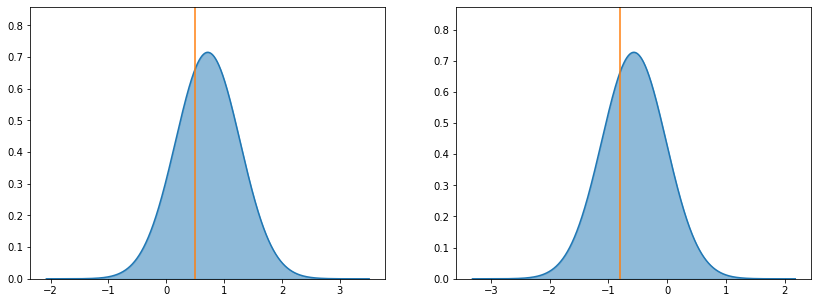

100%|██████████| 9/9 [00:21<00:00,  2.41s/it]


move std 0.98868144 betas [ 0.7059105 -0.5020783] stds:  [0.33010858 0.31895167]


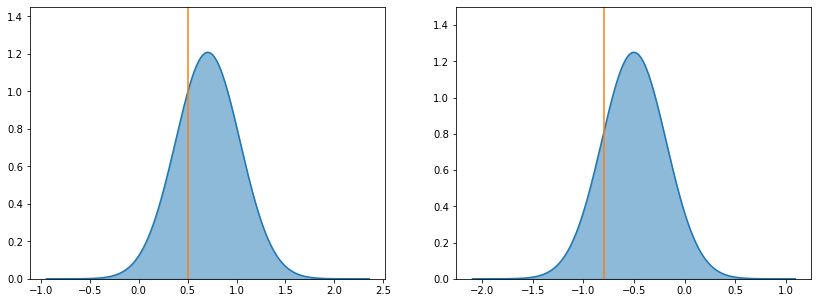

100%|██████████| 9/9 [00:21<00:00,  2.38s/it]


move std 1.0149318 betas [ 0.47805038 -0.397293  ] stds:  [0.22504956 0.21824144]


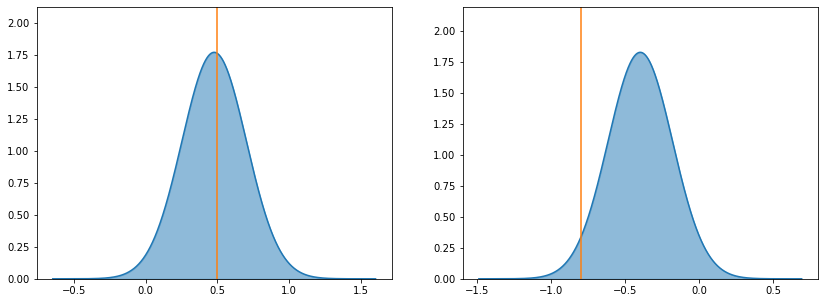

100%|██████████| 9/9 [00:21<00:00,  2.39s/it]


move std 1.0094934 betas [ 0.57878387 -0.45505026] stds:  [0.17469393 0.16807768]


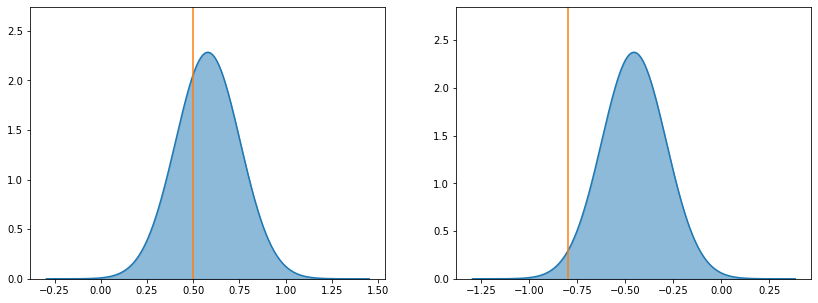

100%|██████████| 9/9 [00:21<00:00,  2.39s/it]


move std 1.0077628 betas [ 0.6179431  -0.48503062] stds:  [0.14758411 0.14038385]


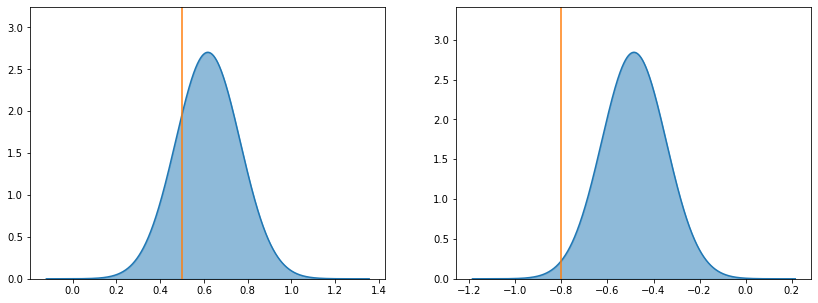

In [10]:
epochs=range(5)

for epoch in epochs:
    epoch_loss = 0.0
    for data_batch in tqdm(train_dataset):
        with tf.GradientTape() as tape:
            loss = ssf.variational_loss(*data_batch, kl_weight)
        epoch_loss+=np.squeeze(loss.numpy())
        gradients=tape.gradient(loss,ssf.trainable_variables)
        optimizer.apply_gradients(zip(gradients, ssf.trainable_variables))
        #break
    plot_fit()

In [11]:
############ Utilisation distribution, and utilisation distribution with uncertainty

# Parameters from the posterior distributions 
b1mean = ssf.beta_mean.numpy()[0] # Mean for cov 1
b1scale = ssf.beta_std.numpy()[0,0] # Standard deviation for cov 1
b2mean = ssf.beta_mean.numpy()[1] # Mean for cov 2
b2scale = ssf.beta_std.numpy()[0,1] # Standard deviation for cov 2

# Estimated, and estimated with uncertainty utilization distribution

######################### Estimated UD without uncertainty ##########################
Es=np.exp(cov1*b1mean + cov2*b2mean)
Es=np.divide(Es,np.sum(Es))

################# Estimated with uncertainty #########################################

# For Covariates 1
Ec1=np.divide(np.exp(cov1*b1mean)*cov1,np.sum(np.exp(cov1*b1mean))) # Expectation E(ci)
Vc1=((cov1**2)-Ec1) # Variance of Var(Ci)
Cdiff1= (cov1-Ec1)**2 
Cdiff1=(Cdiff1-Vc1)
Cdiff1=Cdiff1*(0.5*(b1scale**2))

# For Covariates 2
Ec2=np.divide(np.exp(cov2*b2mean)*cov2,np.sum(np.exp(cov2*b2mean))) # Expectation E(ci)
Vc2=((cov2**2)-Ec2) # Variance of Var(Ci)
Cdiff2= (cov2-Ec2)**2 
Cdiff2=(Cdiff2-Vc2)
Cdiff2=Cdiff2*(0.5*(b2scale**2))

# Sum the Cdiff1 and Cdiff2 and plus them with 1 and multiply it to the utilisation distribution
UD_c=Es*(1 + (Cdiff1 + Cdiff2))

In [12]:
UD_c

array([[0.00023595, 0.00025009, 0.00026557, ..., 0.00018653, 0.00021513,
        0.00023598],
       [0.00028754, 0.00031045, 0.00032553, ..., 0.00020396, 0.00025123,
        0.00028834],
       [0.00038187, 0.00041703, 0.00043094, ..., 0.00024309, 0.00031888,
        0.00038142],
       ...,
       [0.00020972, 0.00021761, 0.00023913, ..., 0.00020235, 0.00020728,
        0.0002097 ],
       [0.00021171, 0.00022093, 0.00023825, ..., 0.00018619, 0.00020184,
        0.00021161],
       [0.00023609, 0.00025031, 0.00026515, ..., 0.00018668, 0.00021533,
        0.00023619]])

In [13]:
Es

array([[0.00023595, 0.00025009, 0.00026557, ..., 0.00018653, 0.00021513,
        0.00023598],
       [0.00028754, 0.00031045, 0.00032553, ..., 0.00020396, 0.00025123,
        0.00028834],
       [0.00038187, 0.00041703, 0.00043094, ..., 0.00024309, 0.00031889,
        0.00038142],
       ...,
       [0.00020972, 0.00021761, 0.00023913, ..., 0.00020235, 0.00020728,
        0.0002097 ],
       [0.00021171, 0.00022093, 0.00023825, ..., 0.00018619, 0.00020184,
        0.00021161],
       [0.00023609, 0.00025031, 0.00026515, ..., 0.00018668, 0.00021533,
        0.00023619]])